# Stellarator isodrasticity — Julia notebook



In [2]:
# Point at the repo root (edit if your notebook lives elsewhere)
const REPO = raw"C:/Users/danie/Stellarator_Isodrasticity"
cd(REPO)
pwd()

"C:\\Users\\danie\\Stellarator_Isodrasticity"

## Load `magnetic_ridge_3` output (JLD2)

Keys are typically `ridge_x`, `ridge_y`, `ridge_z` and full grid `grid_x`, `grid_y`, `grid_z` (`NaN` where no ridge).

In [3]:
using JLD2

ridge_jld2 = joinpath(REPO, "data", "magnetic_ridge3", "magnetic_ridge_3_1.jld2")

rx, ry, rz, meta = jldopen(ridge_jld2, "r") do f
    Vector{Float64}(f["ridge_x"]),
    Vector{Float64}(f["ridge_y"]),
    Vector{Float64}(f["ridge_z"]),
    haskey(f, "meta") ? f["meta"] : nothing
end

println("Ridge points: ", length(rz))
meta

valley_jld2 = joinpath(REPO, "data", "magnetic_ridge_valley3", "magnetic_ridge_valley_3.jld2")

vx, vy, vz, meta2 = jldopen(valley_jld2, "r") do f
    Vector{Float64}(f["valley_x"]),
    Vector{Float64}(f["valley_y"]),
    Vector{Float64}(f["valley_z"]),
    haskey(f, "meta2") ? f["meta2"] : nothing
end
println("Ridge points: ", length(vz))
meta2

Ridge points: 9368
Ridge points: 9883


In [4]:
# Load duplicate multi-root candidates for both magnetic peak and valley datasets
valley_jld2 = joinpath(REPO, "data", "magnetic_ridge_valley3", "magnetic_ridge_valley_3.jld2")

peak_dup = jldopen(ridge_jld2, "r") do f
    if !haskey(f, "multi_ridge_xy_x")
        nothing
    else
        (
            Vector{Float64}(f["multi_ridge_xy_x"]),
            Vector{Float64}(f["multi_ridge_xy_y"]),
            f["multi_ridge_valid_zs"],
            haskey(f, "multi_ridge_chosen_z") ? Vector{Float64}(f["multi_ridge_chosen_z"]) : Float64[],
        )
    end
end

valley_dup = isfile(valley_jld2) ? jldopen(valley_jld2, "r") do f
    if !haskey(f, "multi_valley_xy_x")
        nothing
    else
        (
            Vector{Float64}(f["multi_valley_xy_x"]),
            Vector{Float64}(f["multi_valley_xy_y"]),
            f["multi_valley_valid_zs"],
            haskey(f, "multi_valley_chosen_z") ? Vector{Float64}(f["multi_valley_chosen_z"]) : Float64[],
        )
    end
end : nothing

# Split into explicit x/y/z arrays for plotting
peak_dup_x, peak_dup_y, peak_dup_z = Float64[], Float64[], Float64[]
if peak_dup !== nothing
    px, py, pzs, _ = peak_dup
    for i in eachindex(pzs)
        for z in pzs[i]
            push!(peak_dup_x, px[i]); push!(peak_dup_y, py[i]); push!(peak_dup_z, z)
        end
    end
end

valley_dup_x, valley_dup_y, valley_dup_z = Float64[], Float64[], Float64[]
if valley_dup !== nothing
    vdx, vdy, vzs, _ = valley_dup
    for i in eachindex(vzs)
        for z in vzs[i]
            push!(valley_dup_x, vdx[i]); push!(valley_dup_y, vdy[i]); push!(valley_dup_z, z)
        end
    end
end

if peak_dup === nothing
    println("Peak duplicates: none found in $(ridge_jld2)")
else
    println("Peak duplicate XY columns: ", length(peak_dup[1]), " | expanded points: ", length(peak_dup_z))
end

if valley_dup === nothing
    println("Valley duplicates: none found (missing file or keys): $(valley_jld2)")
else
    println("Valley duplicate XY columns: ", length(valley_dup[1]), " | expanded points: ", length(valley_dup_z))
end

peak_dup_x, peak_dup_y, peak_dup_z, valley_dup_x, valley_dup_y, valley_dup_z

Peak duplicate XY columns: 435 | expanded points: 897
Valley duplicate XY columns: 91 | expanded points: 186


([-1.3648907034916962, -1.3648907034916962, -1.3648907034916962, -1.3648907034916962, -1.3648907034916962, -1.3648907034916962, -1.3511754776090132, -1.3511754776090132, -1.3511754776090132, -1.3511754776090132  …  1.1998565365700122, 1.1998565365700122, 1.2135717624526952, 1.2135717624526952, 1.3370087953968415, 1.3370087953968415, 1.3370087953968415, 1.3370087953968415, 1.3370087953968415, 1.3370087953968415], [-0.23621405114274555, -0.23621405114274555, -0.22418936613705215, -0.22418936613705215, -0.21216468113135878, -0.21216468113135878, -0.23621405114274555, -0.23621405114274555, -0.22418936613705215, -0.22418936613705215  …  -0.6089792863192406, -0.6089792863192406, -0.6089792863192406, -0.6089792863192406, 0.16060055404513623, 0.16060055404513623, 0.17262523905082963, 0.17262523905082963, 0.18464992405652303, 0.18464992405652303], [-0.368411382381483, 0.03406372635603583, -0.3248408214052953, -0.027769997668709547, -0.274764550352666, -0.10040528726989352, -0.3956635716365682, 

## Quick 3D scatter 

Blue for main values, gold for duplicate

In [ ]:
using GLMakie

R = sqrt.(rx .^ 2 .+ ry .^ 2)
fig = Figure(size = (800, 600))
ax = Axis3(fig[1, 1]; title = "Ridge points", aspect = :data)


scatter!(ax, rx, ry, rz; color = :blue,  markersize = 8)

#scatter!(ax, vx, vy, vz; color = :gold,  markersize = 8)

#Load duplicates




    
    
scatter!(ax, peak_dup_x, peak_dup_y, peak_dup_z; color = :purple, markersize = 10)
    
#scatter!(ax, valley_dup_x, valley_dup_y, valley_dup_z; color = :green, markersize = 10)



z_plane = 0.0
Rmax = maximum(hypot.(rx, ry)) * 1.05
angle_step_deg = 15
ring_count = 4
θc = range(0, 2π; length = 361)
for j in 1:ring_count
    rj = Rmax * j / ring_count
    lines!(ax, rj .* cos.(θc), rj .* sin.(θc), fill(z_plane, length(θc));
           color = (:gray, 0.35), linewidth = 1)
end
for deg in 0:angle_step_deg:330
    θ = deg2rad(deg)
    x2, y2 = Rmax * cos(θ), Rmax * sin(θ)
    lines!(ax, [0.0, x2], [0.0, y2], [z_plane, z_plane];
           color = (:black, 0.45), linewidth = 1.5)
    rl = 1.08 * Rmax
    text!(ax, rl * cos(θ), rl * sin(θ), z_plane;
          text = "$(deg)°", align = (:center, :center), fontsize = 12, color = :black)
end
text!(ax,  1.15Rmax, 0.0,      z_plane; text = "+x", fontsize = 14, color = :red)
text!(ax, -1.15Rmax, 0.0,      z_plane; text = "-x", fontsize = 14, color = :red)
text!(ax, 0.0,       1.15Rmax, z_plane; text = "+y", fontsize = 14, color = :blue)
text!(ax, 0.0,      -1.15Rmax, z_plane; text = "-y", fontsize = 14, color = :blue)
scatter!(ax, [0.0], [0.0], [z_plane]; color = :black, markersize = 10)

fig

In [6]:
# Remove small outer-edge angle clusters and replot
using Statistics
using WGLMakie
WGLMakie.activate!()

# --- inputs from earlier cells ---
# rx, ry, rz

# Cylindrical coordinates
R   = hypot.(rx, ry)
phi = mod.(rad2deg.(atan.(ry, rx)), 360.0)  # [0, 360)

# Target angles (deg) where tiny edge clusters appear
target_angles = [75.0, 105.0, 255.0, 285.0]

# Tunable thresholds
angle_half_width = 8.0      # keep this around each target angle (deg)
outer_quantile   = 0.70     # only remove points in outer 10% radius
# If too aggressive, raise to 0.93-0.97 or reduce angle_half_width.

r_cut = quantile(R, outer_quantile)

# Circular angular distance in degrees
angdist(a, b) = abs(mod(a - b + 180, 360) - 180)

# Mark points near any target angle and on outer radius
near_target = [minimum(angdist(p, t) for t in target_angles) <= angle_half_width for p in phi]
outer_edge  = R .>= r_cut

remove_mask = near_target .& outer_edge
keep_mask   = .!remove_mask

# Filtered arrays
rx_f, ry_f, rz_f = rx[keep_mask], ry[keep_mask], rz[keep_mask]
rx_rm, ry_rm, rz_rm = rx[remove_mask], ry[remove_mask], rz[remove_mask]

println("Original points: ", length(rx))
println("Removed points : ", length(rx_rm))
println("Kept points    : ", length(rx_f))
println("r_cut (q=$(outer_quantile)) = ", r_cut)

# Replot: kept (blue), removed (red)
fig_clean = Figure(size = (900, 700))
ax_clean = Axis3(fig_clean[1, 1]; title = "Filtered ridge points (outer-angle clusters removed)", aspect = :data)

scatter!(ax_clean, rx_f,  ry_f,  rz_f;  color = (:dodgerblue, 0.85), markersize = 7)
if !isempty(rx_rm)
    scatter!(ax_clean, rx_rm, ry_rm, rz_rm; color = (:red, 0.95), markersize = 11)
end

fig_clean

Original points: 9368
Removed points : 130
Kept points    : 9238
r_cut (q=0.7) = 1.121830163741195


In [7]:
using WGLMakie
WGLMakie.activate!()

# Replot: kept (blue), removed (red)
fig_clean = Figure(size = (900, 700))
ax_clean = Axis3(fig_clean[1, 1]; title = "Filtered ridge points (outer-angle clusters removed)", aspect = :data)

scatter!(ax_clean, rx_f,  ry_f,  rz_f;  color = (:dodgerblue, 0.85), markersize = 7)

z_plane = 0.0
Rmax = maximum(hypot.(rx, ry)) * 1.05
angle_step_deg = 15
ring_count = 4
θc = range(0, 2π; length = 361)
for j in 1:ring_count
    rj = Rmax * j / ring_count
    lines!(ax_clean, rj .* cos.(θc), rj .* sin.(θc), fill(z_plane, length(θc));
           color = (:gray, 0.35), linewidth = 1)
end
for deg in 0:angle_step_deg:330
    θ = deg2rad(deg)
    x2, y2 = Rmax * cos(θ), Rmax * sin(θ)
    lines!(ax_clean, [0.0, x2], [0.0, y2], [z_plane, z_plane];
           color = (:black, 0.45), linewidth = 1.5)
    rl = 1.08 * Rmax
    text!(ax_clean, rl * cos(θ), rl * sin(θ), z_plane;
          text = "$(deg)°", align = (:center, :center), fontsize = 12, color = :black)
end
text!(ax_clean,  1.15Rmax, 0.0,      z_plane; text = "+x", fontsize = 14, color = :red)
text!(ax_clean, -1.15Rmax, 0.0,      z_plane; text = "-x", fontsize = 14, color = :red)
text!(ax_clean, 0.0,       1.15Rmax, z_plane; text = "+y", fontsize = 14, color = :blue)
text!(ax_clean, 0.0,      -1.15Rmax, z_plane; text = "-y", fontsize = 14, color = :blue)
scatter!(ax_clean, [0.0], [0.0], [z_plane]; color = :black, markersize = 10)


fig_clean


In [8]:
# Split points into fixed angle sectors (degrees), then plot each sector
using WGLMakie
WGLMakie.activate!()

# Split FIXED angle sectors on FILTERED data (rx_f, ry_f, rz_f)
using Statistics


# --- filtered inputs from your removal cell ---
xv, yv, zv = rx_f, ry_f, rz_f
@assert length(xv) == length(yv) == length(zv)

phi_deg = mod.(rad2deg.(atan.(yv, xv)), 360.0)

edges  = [0.0, 15.0, 75.0, 105.0, 165.0, 180.0, 195.0, 255.0, 285.0, 345.0, 360.0]
labels = [
    "0-15", "15-75", "75-105", "105-165", "165-180",
    "180-195", "195-255", "255-285", "285-345", "345-360"
]

K = length(labels)
@assert length(edges) == K + 1

sector_masks = Vector{BitVector}(undef, K)
cluster_xs_f = Vector{Vector{Float64}}(undef, K)
cluster_ys_f = Vector{Vector{Float64}}(undef, K)
cluster_zs_f = Vector{Vector{Float64}}(undef, K)
labels_fixed_f = zeros(Int, length(phi_deg))

for j in 1:K
    lo, hi = edges[j], edges[j+1]
    m = (j < K) ? ((phi_deg .>= lo) .& (phi_deg .< hi)) : ((phi_deg .>= lo) .& (phi_deg .<= hi))
    sector_masks[j] = m
    cluster_xs_f[j] = xv[m]
    cluster_ys_f[j] = yv[m]
    cluster_zs_f[j] = zv[m]
    labels_fixed_f[m] .= j
end

println("Filtered fixed-angle sector sizes:")
for j in 1:K
    println(rpad("  Sector $(j) ($(labels[j])):", 24), length(cluster_xs_f[j]))
end

# Plot filtered data colored by fixed sector
pal = Makie.wong_colors()
colors_f = [pal[mod1(labels_fixed_f[i], length(pal))] for i in eachindex(labels_fixed_f)]

fig_sec_f = Figure(size = (950, 720))
ax_sec_f = Axis3(fig_sec_f[1, 1]; title = "Filtered data: fixed angle sectors", aspect = :data)
scatter!(ax_sec_f, xv, yv, zv; color = colors_f, markersize = 8)
fig_sec_f

Filtered fixed-angle sector sizes:
  Sector 1 (0-15):      379
  Sector 2 (15-75):     1591
  Sector 3 (75-105):    667
  Sector 4 (105-165):   1716
  Sector 5 (165-180):   332
  Sector 6 (180-195):   398
  Sector 7 (195-255):   1591
  Sector 8 (255-285):   629
  Sector 9 (285-345):   1592
  Sector 10 (345-360):  343


In [9]:
# Fit one plane per filtered angle-sector cluster:
# z = a*x + b*y + c  (2D linear regression in x,y -> z)
using LinearAlgebra
using Statistics
using WGLMakie
WGLMakie.activate!()
using StaticArrays

# expects from previous cell:
# cluster_xs_f, cluster_ys_f, cluster_zs_f, labels (or define labels here)
if !(@isdefined labels)
    labels = ["0-15","15-75","75-105","105-165","165-180","180-195","195-255","255-285","285-345","345-360"]
end

K = length(cluster_xs_f)
@assert K == length(cluster_ys_f) == length(cluster_zs_f)

# Storage
plane_coeffs = Vector{NTuple{3,Float64}}(undef, K)   # (a,b,c)
plane_rmse   = fill(NaN, K)
plane_r2     = fill(NaN, K)
plane_normals = Vector{SVector{3,Float64}}(undef, K) # normal to plane: [a,b,-1] normalized

# Fit each sector
for j in 1:K
    xj, yj, zj = cluster_xs_f[j], cluster_ys_f[j], cluster_zs_f[j]
    n = length(zj)
    if n < 3
        plane_coeffs[j] = (NaN, NaN, NaN)
        plane_normals[j] = SA[NaN, NaN, NaN]
        @warn "Sector $(j) ($(labels[j])) has <3 points; skipping plane fit."
        continue
    end

    X = hcat(xj, yj, ones(n))      # [x y 1]
    β = X \ zj                      # least-squares [a,b,c]
    a, b, c = β

    zhat = X * β
    resid = zj .- zhat
    sse = sum(abs2, resid)
    sst = sum(abs2, zj .- mean(zj))

    rmse = sqrt(sse / n)
    r2 = sst > 0 ? 1 - sse/sst : NaN

    plane_coeffs[j] = (a, b, c)
    plane_rmse[j] = rmse
    plane_r2[j] = r2

    nvec = SA[a, b, -1.0]
    plane_normals[j] = nvec / norm(nvec)

    println("Sector $(j) ($(labels[j])): z = $(round(a,digits=6))x + $(round(b,digits=6))y + $(round(c,digits=6))",
            " | n=$(n), RMSE=$(round(rmse,digits=6)), R²=$(round(r2,digits=6))")
end

# ---- Plot data + fitted plane for each sector ----
ncols = min(3, K)
nrows = cld(K, ncols)
fig_planes = Figure(size = (420*ncols + 60, 360*nrows + 40))
pal = Makie.wong_colors()

for j in 1:K
    r = div(j-1, ncols) + 1
    cidx = mod(j-1, ncols) + 1
    ax = Axis3(fig_planes[r, cidx];
        title = "Sector $(j) ($(labels[j]))\nRMSE=$(round(plane_rmse[j],digits=4))  R²=$(round(plane_r2[j],digits=4))",
        aspect = :data
    )

    xj, yj, zj = cluster_xs_f[j], cluster_ys_f[j], cluster_zs_f[j]
    scatter!(ax, xj, yj, zj; color = pal[mod1(j, length(pal))], markersize = 7)

    a, b, cc = plane_coeffs[j]
    if !isnan(a) && !isempty(xj)
        xr = range(minimum(xj), maximum(xj); length=25)
        yr = range(minimum(yj), maximum(yj); length=25)
        Xg = [x for x in xr, _ in yr]
        Yg = [y for _ in xr, y in yr]
        Zg = a .* Xg .+ b .* Yg .+ cc
        surface!(ax, Xg, Yg, Zg; alpha=0.45, colormap=:viridis, shading=true)
    end
end

fig_planes

Sector 1 (0-15): z = 0.093156x + 0.754324y + -0.216698 | n=379, RMSE=0.08231, R²=0.20812
Sector 2 (15-75): z = -0.079409x + -0.249112y + 0.360979 | n=1591, RMSE=0.041119, R²=0.457648
Sector 3 (75-105): z = 0.312808x + -0.003206y + 0.002677 | n=667, RMSE=0.006043, R²=0.917564
Sector 4 (105-165): z = -0.076652x + 0.286062y + -0.383282 | n=1716, RMSE=0.038025, R²=0.575933
Sector 5 (165-180): z = -0.31799x + -1.023118y + -0.233805 | n=332, RMSE=0.058468, R²=0.448925
Sector 6 (180-195): z = -0.401992x + 0.112577y + -0.444377 | n=398, RMSE=0.138032, R²=0.091815
Sector 7 (195-255): z = 0.196849x + 0.255479y + 0.425744 | n=1591, RMSE=0.089538, R²=0.261936
Sector 8 (255-285): z = -0.303181x + 0.00098y + 0.000902 | n=629, RMSE=0.00592, R²=0.915683
Sector 9 (285-345): z = 0.284188x + -0.469531y + -0.624038 | n=1592, RMSE=0.088996, R²=0.465577
Sector 10 (345-360): z = 0.172244x + 1.023363y + -0.050061 | n=343, RMSE=0.061973, R²=0.398346


In [10]:
# Per-sector plane (u,v) coordinates: orthogonal projection onto fitted plane z = a*x + b*y + c
using LinearAlgebra
using Statistics
using WGLMakie
WGLMakie.activate!()

@assert isdefined(Main, :cluster_xs_f) && isdefined(Main, :cluster_ys_f) && isdefined(Main, :cluster_zs_f)
@assert isdefined(Main, :plane_coeffs)

K = length(cluster_xs_f)

function plane_uv_coords(x::Vector{Float64}, y::Vector{Float64}, z::Vector{Float64}, a::Float64, b::Float64, c::Float64)
    n = length(z)
    n < 3 && return Float64[], Float64[]

    # Plane: a*x + b*y - z + c = 0  <=>  n_u·[x,y,z] + c = 0  with n_u = [a,b,-1]
    n_u = Float64[a, b, -1.0]
    nn = dot(n_u, n_u)
    nn == 0 && return Float64[], Float64[]

    # Point on plane (works whenever c is finite)
    p0 = Float64[0.0, 0.0, c]

    n_hat = n_u / sqrt(nn)

    # Orthonormal tangent basis in the plane
    zax = Float64[0.0, 0.0, 1.0]
    e1 = cross(n_hat, zax)
    if norm(e1) < 1e-12
        e1 = cross(n_hat, Float64[1.0, 0.0, 0.0])
    end
    e1 = normalize(e1)
    e2 = normalize(cross(n_hat, e1))  # unit, ⟂ n_hat, ⟂ e1

    u = Vector{Float64}(undef, n)
    v = Vector{Float64}(undef, n)

    @inbounds for i in 1:n
        p = Float64[x[i], y[i], z[i]]
        # Orthogonal projection onto plane
        t = (dot(n_u, p) + c) / nn
        pp = p .- t .* n_u

        du = pp .- p0
        u[i] = dot(du, e1)
        v[i] = dot(du, e2)
    end

    return u, v
end

cluster_u = Vector{Vector{Float64}}(undef, K)
cluster_v = Vector{Vector{Float64}}(undef, K)

println("Sector (u,v) counts:")
for j in 1:K
    xj, yj, zj = cluster_xs_f[j], cluster_ys_f[j], cluster_zs_f[j]
    aj, bj, cj = plane_coeffs[j]
    if any(isnan, (aj, bj, cj)) || length(zj) < 3
        cluster_u[j] = Float64[]
        cluster_v[j] = Float64[]
        println("  sector ", j, ": skipped")
        continue
    end
    uj, vj = plane_uv_coords(xj, yj, zj, Float64(aj), Float64(bj), Float64(cj))
    cluster_u[j] = uj
    cluster_v[j] = vj
    println("  sector ", j, ": n=", length(uj))
end

# Quick 2D overview: one subplot per sector in (u,v)
ncols = min(3, K)
nrows = cld(K, ncols)
fig_uv = Figure(size = (360*ncols + 40, 300*nrows + 30))
pal = Makie.wong_colors()

for j in 1:K
    r = div(j-1, ncols) + 1
    cc = mod(j-1, ncols) + 1
    ax = Axis(fig_uv[r, cc]; title = "Sector $j (u,v)", aspect = DataAspect())
    uj, vj = cluster_u[j], cluster_v[j]
    isempty(uj) && continue
    scatter!(ax, uj, vj; color = pal[mod1(j, length(pal))], markersize = 6)
end

fig_uv

Sector (u,v) counts:
  sector 1: n=379
  sector 2: n=1591
  sector 3: n=667
  sector 4: n=1716
  sector 5: n=332
  sector 6: n=398
  sector 7: n=1591
  sector 8: n=629
  sector 9: n=1592
  sector 10: n=343


In [11]:
# Polynomial–Fourier least squares on each sector, using plane (u,v) polar coords (ρ,φ)
using LinearAlgebra
using Printf
using WGLMakie
WGLMakie.activate!()

# --- expects from earlier cells ---
# cluster_u, cluster_v, cluster_zs_f, labels (optional)
if !isdefined(Main, :labels)
    labels = ["0-15","15-75","75-105","105-165","165-180",
              "180-195","195-255","255-285","285-345","345-360"]
end

K = length(cluster_zs_f)
@assert length(cluster_u) == K == length(cluster_v)

# Model orders (edit freely)
M_rad = 1
N_tor = 2

function n_coefficients(M::Int, N::Int)
    (M + 1) + N * (M + 1) * 2
end

function design_matrix(R::AbstractVector{Float64}, phi::AbstractVector{Float64}, M::Int, N::Int)
    npts = length(R)
    @assert length(phi) == npts
    ncols = n_coefficients(M, N)
    A = zeros(npts, ncols)
    col = 1
    @inbounds for m in 0:M
        A[:, col] .= R .^ m
        col += 1
    end
    for n in 1:N
        @inbounds for m in 0:M
            A[:, col] .= (R .^ m) .* cos.(n .* phi)
            col += 1
            A[:, col] .= (R .^ m) .* sin.(n .* phi)
            col += 1
        end
    end
    @assert col == ncols + 1
    return A
end

function predict_z(R::AbstractArray{Float64}, phi::AbstractArray{Float64}, c::AbstractVector{Float64}, M::Int, N::Int)
    z = zeros(Float64, size(R))
    k = 1
    @inbounds for m in 0:M
        z .+= c[k] .* (R .^ m)
        k += 1
    end
    for n in 1:N
        @inbounds for m in 0:M
            z .+= c[k] .* ((R .^ m) .* cos.(n .* phi))
            k += 1
            z .+= c[k] .* ((R .^ m) .* sin.(n .* phi))
            k += 1
        end
    end
    return z
end

sector_plane_cs = Vector{Vector{Float64}}(undef, K)
sector_plane_rmses = fill(NaN, K)

for j in 1:K
    uj, vj, zj = cluster_u[j], cluster_v[j], cluster_zs_f[j]
    n = length(zj)
    if n < n_coefficients(M_rad, N_tor)
        sector_plane_cs[j] = Float64[]
        @warn @sprintf("Sector %d (%s): not enough points (n=%d) for this (M,N).",
                      j, labels[j], n)
        continue
    end

    rho = hypot.(uj, vj)
    phi = atan.(vj, uj)

    A = design_matrix(rho, phi, M_rad, N_tor)
    cj = A \ zj
    zh = A * cj

    sector_plane_cs[j] = cj
    sector_plane_rmses[j] = sqrt(sum(abs2, zj .- zh) / n)

    println(@sprintf("Sector %2d (%s): n=%5d  RMSE=%.6g  (M=%d, N=%d)",
                     j, labels[j], n, sector_plane_rmses[j], M_rad, N_tor))
end



SURF_NR = 80
SURF_NPHI = 120

ncols = min(3, K)
nrows = cld(K, ncols)
pal = Makie.wong_colors()

fig_pf = Figure(size = (460*ncols + 60, 380*nrows + 40))

for j in 1:K
    r = div(j-1, ncols) + 1
    cc = mod(j-1, ncols) + 1
    ax = Axis3(fig_pf[r, cc];
        title = @sprintf("Sector %d (%s)  RMSE=%.4g", j, labels[j], sector_plane_rmses[j]),
        aspect = :data,
    )

    uj, vj, zj = cluster_u[j], cluster_v[j], cluster_zs_f[j]
    cj = sector_plane_cs[j]
    isempty(uj) && continue
    isempty(cj) && continue

    clr = pal[mod1(j, length(pal))]
    scatter!(ax, uj, vj, zj; color = clr, markersize = 5)

    rho = hypot.(uj, vj)
    phi = atan.(vj, uj)

    # Avoid rho=0 blowups + avoid extrapolating to crazy radii
    rho_pos = maximum((minimum(rho), 1e-9))
    rlo = quantile(rho, 0.02)
    rhi = quantile(rho, 0.98)
    rlo = max(rlo, rho_pos)
    (rhi > rlo) || continue

    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)

    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)

    surface!(ax, Umat, Vmat, Zmat;
        colormap = :viridis,
        alpha = 0.35,
        shading = NoShading,   # big visual stability win
    )
end

fig_pf

Sector  1 (0-15): n=  379  RMSE=0.027486  (M=1, N=2)
Sector  2 (15-75): n= 1591  RMSE=0.0190444  (M=1, N=2)
Sector  3 (75-105): n=  667  RMSE=0.00114301  (M=1, N=2)
Sector  4 (105-165): n= 1716  RMSE=0.0165445  (M=1, N=2)
Sector  5 (165-180): n=  332  RMSE=0.0134863  (M=1, N=2)
Sector  6 (180-195): n=  398  RMSE=0.0623344  (M=1, N=2)
Sector  7 (195-255): n= 1591  RMSE=0.0508425  (M=1, N=2)
Sector  8 (255-285): n=  629  RMSE=0.00111531  (M=1, N=2)
Sector  9 (285-345): n= 1592  RMSE=0.0465227  (M=1, N=2)
Sector 10 (345-360): n=  343  RMSE=0.0160738  (M=1, N=2)


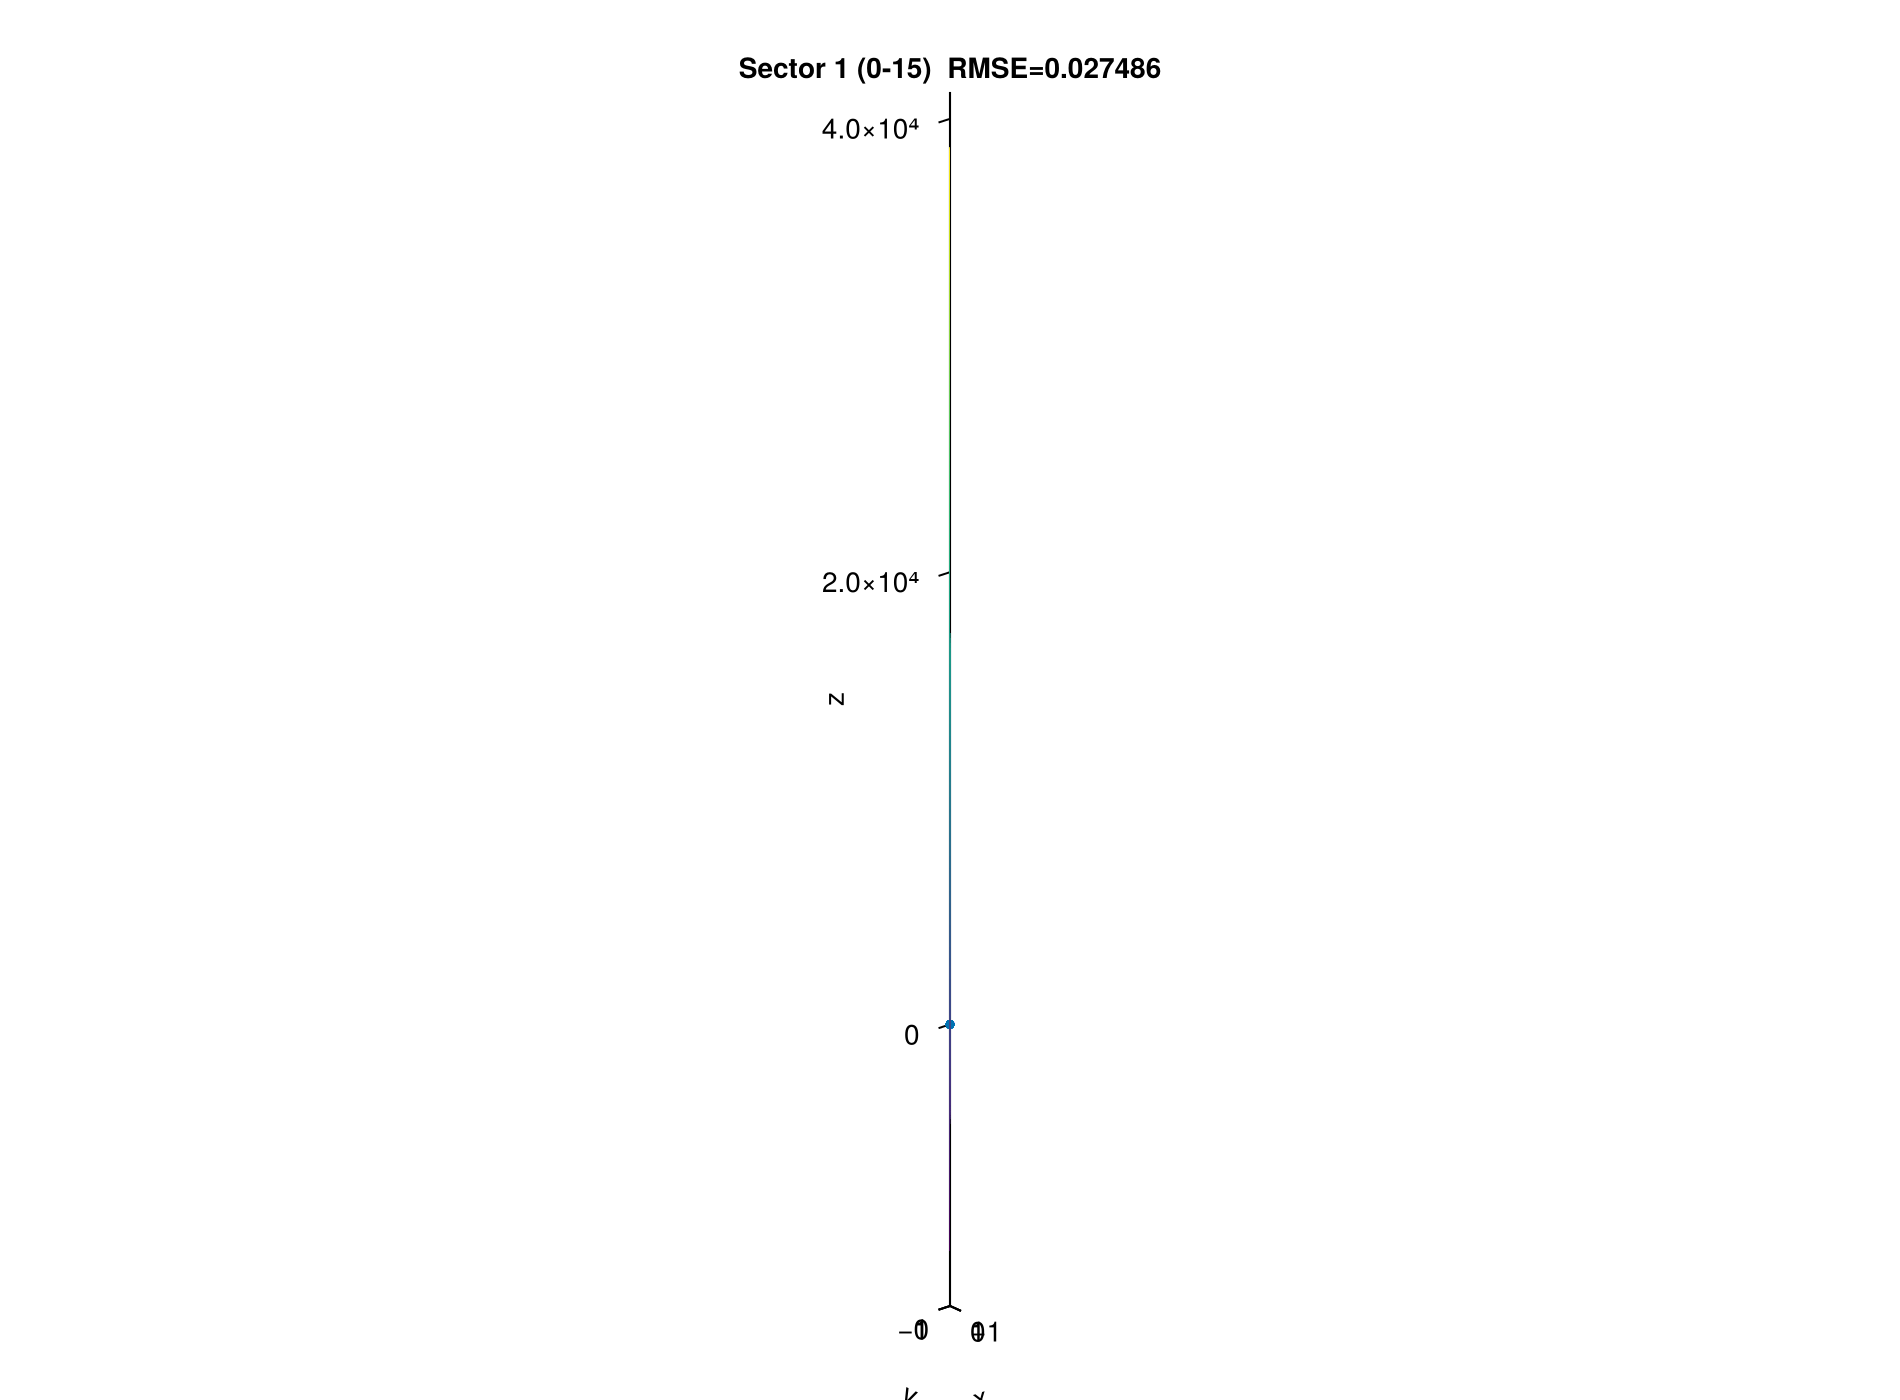

In [16]:
using WGLMakie
WGLMakie.activate!()
using Printf
using Statistics

sj = 1
if !isdefined(Main, :labels)
    labels = ["0-15", "15-75", "75-105", "105-165", "165-180", "180-195", "195-255", "255-285", "285-345", "345-360"]
end
uj, vj, zj = cluster_u[sj], cluster_v[sj], cluster_zs_f[sj]
cj = sector_plane_cs[sj]
isempty(uj) && error("Sector $(sj): no (u,v) data — run the (u,v) cell first.")
isempty(cj) && error("Sector $(sj): no fit coefficients — run the polynomial–Fourier fit cell first.")

fig = Figure(size = (950, 700))
ax = Axis3(fig[1, 1]; title = @sprintf("Sector %d (%s)  RMSE=%.5g", sj, labels[sj], sector_plane_rmses[sj]), aspect = :data)
pal = Makie.wong_colors()
scatter!(ax, uj, vj, zj; color = pal[mod1(sj, length(pal))], markersize = 6)
rho = hypot.(uj, vj)
rho_pos = max(minimum(rho), 1e-9)
rlo = quantile(rho, 0.02)
rhi = quantile(rho, 0.98)
rlo = max(rlo, rho_pos)
if rhi > rlo
    SURF_NR = 100
    SURF_NPHI = 120
    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)
    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)
    surface!(ax, Umat, Vmat, Zmat; colormap = :viridis, alpha = 0.38, shading = NoShading)
end
fig

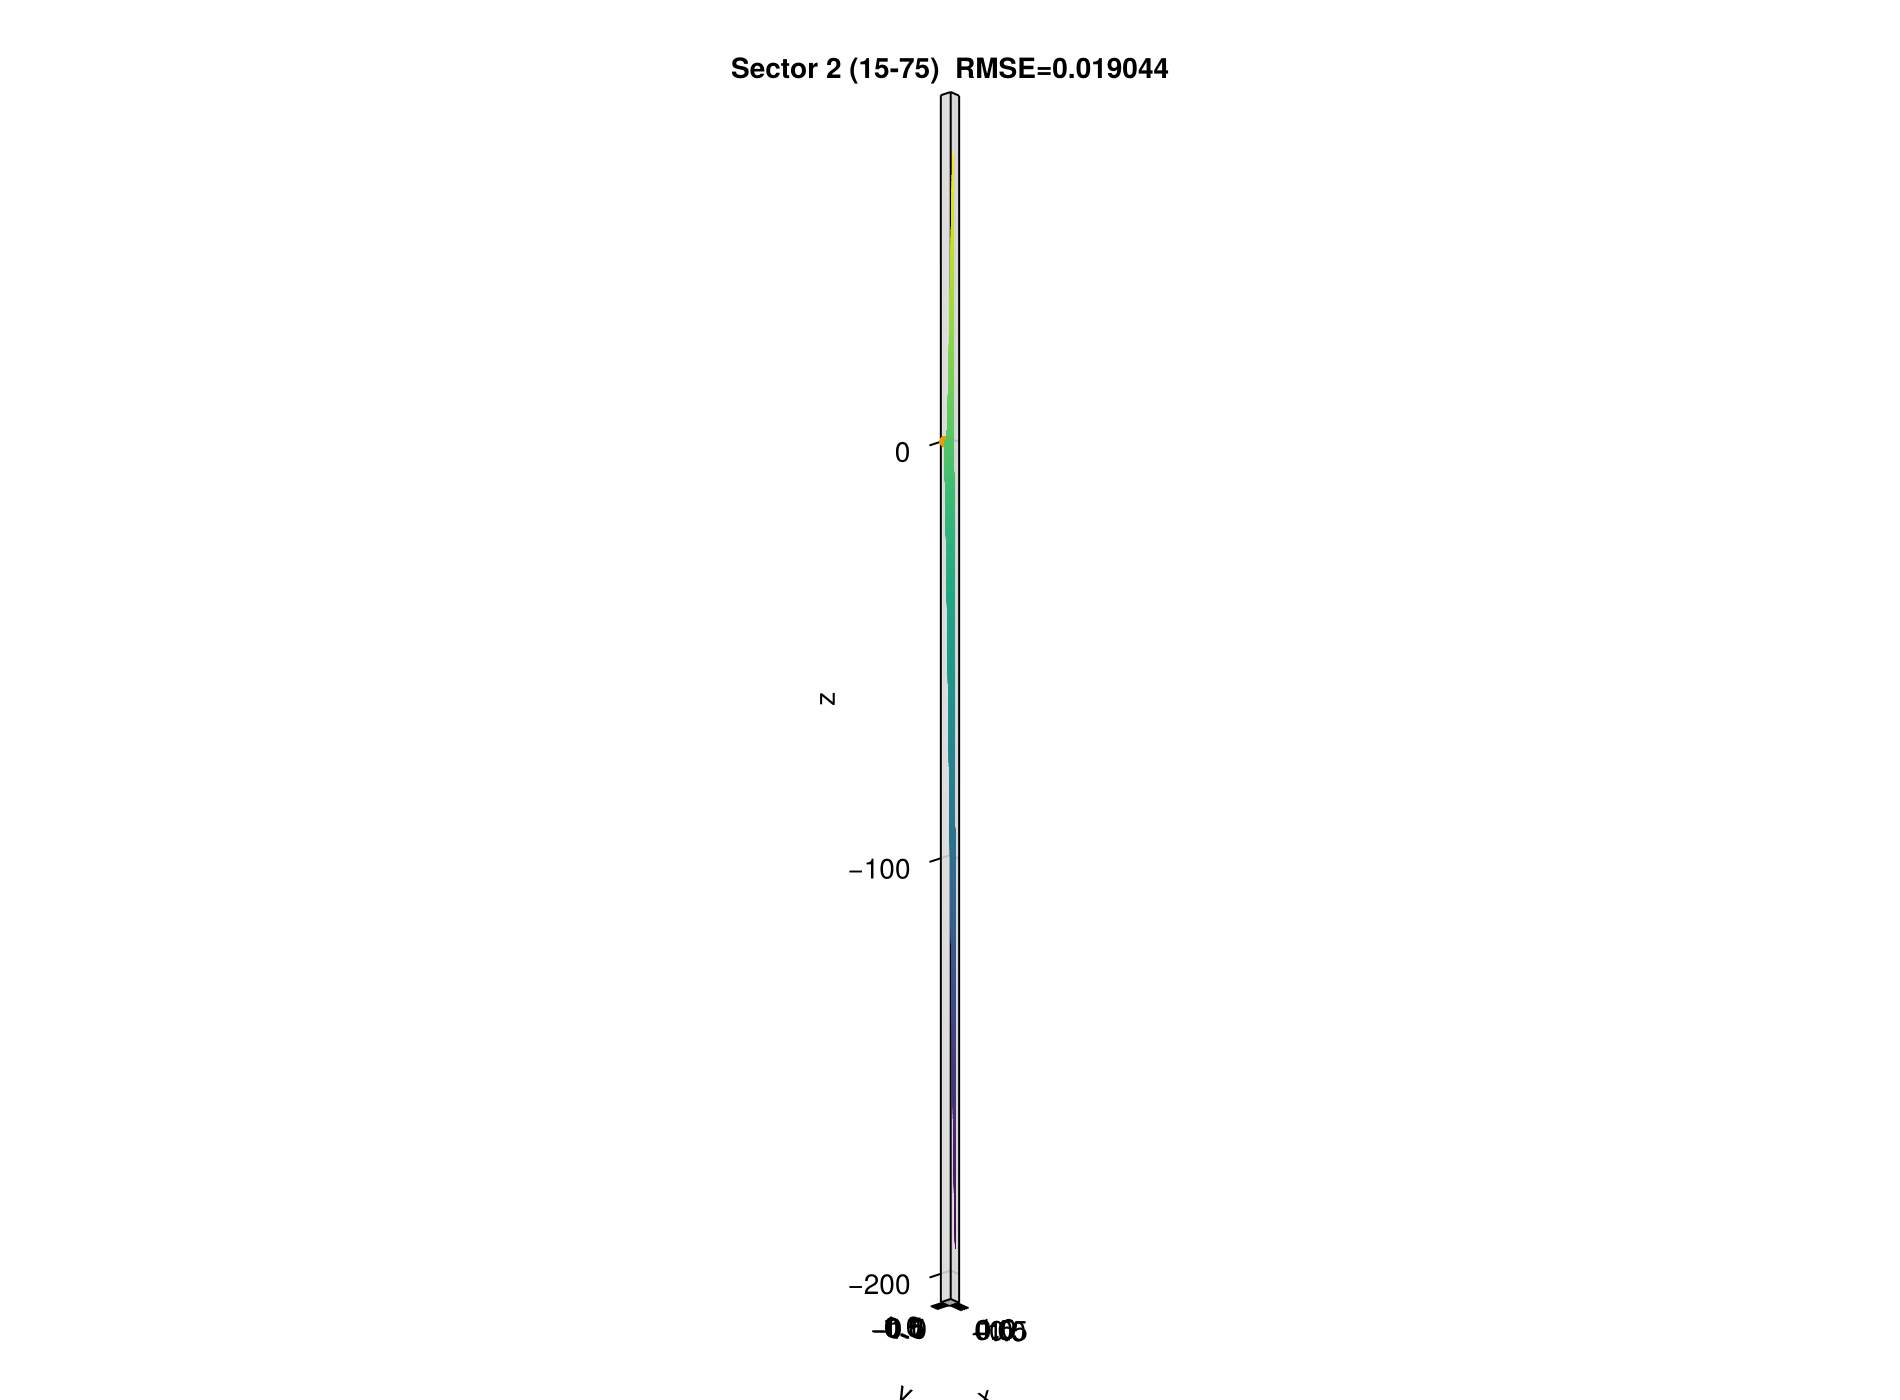

In [15]:
using WGLMakie
WGLMakie.activate!()
using Printf
using Statistics

sj = 2
if !isdefined(Main, :labels)
    labels = ["0-15", "15-75", "75-105", "105-165", "165-180", "180-195", "195-255", "255-285", "285-345", "345-360"]
end
uj, vj, zj = cluster_u[sj], cluster_v[sj], cluster_zs_f[sj]
cj = sector_plane_cs[sj]
isempty(uj) && error("Sector $(sj): no (u,v) data — run the (u,v) cell first.")
isempty(cj) && error("Sector $(sj): no fit coefficients — run the polynomial–Fourier fit cell first.")

fig = Figure(size = (950, 700))
ax = Axis3(fig[1, 1]; title = @sprintf("Sector %d (%s)  RMSE=%.5g", sj, labels[sj], sector_plane_rmses[sj]), aspect = :data)
pal = Makie.wong_colors()
scatter!(ax, uj, vj, zj; color = pal[mod1(sj, length(pal))], markersize = 6)
rho = hypot.(uj, vj)
rho_pos = max(minimum(rho), 1e-9)
rlo = quantile(rho, 0.02)
rhi = quantile(rho, 0.98)
rlo = max(rlo, rho_pos)
if rhi > rlo
    SURF_NR = 100
    SURF_NPHI = 120
    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)
    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)
    surface!(ax, Umat, Vmat, Zmat; colormap = :viridis, alpha = 0.38, shading = NoShading)
end
fig

In [ ]:
using CairoMakie
using Printf
using Statistics

sj = 3
if !isdefined(Main, :labels)
    labels = ["0-15", "15-75", "75-105", "105-165", "165-180", "180-195", "195-255", "255-285", "285-345", "345-360"]
end
uj, vj, zj = cluster_u[sj], cluster_v[sj], cluster_zs_f[sj]
cj = sector_plane_cs[sj]
isempty(uj) && error("Sector $(sj): no (u,v) data — run the (u,v) cell first.")
isempty(cj) && error("Sector $(sj): no fit coefficients — run the polynomial–Fourier fit cell first.")

fig = Figure(size = (950, 700))
ax = Axis3(fig[1, 1]; title = @sprintf("Sector %d (%s)  RMSE=%.5g", sj, labels[sj], sector_plane_rmses[sj]), aspect = :data)
pal = Makie.wong_colors()
scatter!(ax, uj, vj, zj; color = pal[mod1(sj, length(pal))], markersize = 6)
rho = hypot.(uj, vj)
rho_pos = max(minimum(rho), 1e-9)
rlo = quantile(rho, 0.02)
rhi = quantile(rho, 0.98)
rlo = max(rlo, rho_pos)
if rhi > rlo
    SURF_NR = 100
    SURF_NPHI = 120
    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)
    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)
    surface!(ax, Umat, Vmat, Zmat; colormap = :viridis, alpha = 0.38, shading = NoShading)
end
fig

In [ ]:
using CairoMakie
using Printf
using Statistics

sj = 4
if !isdefined(Main, :labels)
    labels = ["0-15", "15-75", "75-105", "105-165", "165-180", "180-195", "195-255", "255-285", "285-345", "345-360"]
end
uj, vj, zj = cluster_u[sj], cluster_v[sj], cluster_zs_f[sj]
cj = sector_plane_cs[sj]
isempty(uj) && error("Sector $(sj): no (u,v) data — run the (u,v) cell first.")
isempty(cj) && error("Sector $(sj): no fit coefficients — run the polynomial–Fourier fit cell first.")

fig = Figure(size = (950, 700))
ax = Axis3(fig[1, 1]; title = @sprintf("Sector %d (%s)  RMSE=%.5g", sj, labels[sj], sector_plane_rmses[sj]), aspect = :data)
pal = Makie.wong_colors()
scatter!(ax, uj, vj, zj; color = pal[mod1(sj, length(pal))], markersize = 6)
rho = hypot.(uj, vj)
rho_pos = max(minimum(rho), 1e-9)
rlo = quantile(rho, 0.02)
rhi = quantile(rho, 0.98)
rlo = max(rlo, rho_pos)
if rhi > rlo
    SURF_NR = 100
    SURF_NPHI = 120
    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)
    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)
    surface!(ax, Umat, Vmat, Zmat; colormap = :viridis, alpha = 0.38, shading = NoShading)
end
fig

In [ ]:
using CairoMakie
using Printf
using Statistics

sj = 5
if !isdefined(Main, :labels)
    labels = ["0-15", "15-75", "75-105", "105-165", "165-180", "180-195", "195-255", "255-285", "285-345", "345-360"]
end
uj, vj, zj = cluster_u[sj], cluster_v[sj], cluster_zs_f[sj]
cj = sector_plane_cs[sj]
isempty(uj) && error("Sector $(sj): no (u,v) data — run the (u,v) cell first.")
isempty(cj) && error("Sector $(sj): no fit coefficients — run the polynomial–Fourier fit cell first.")

fig = Figure(size = (950, 700))
ax = Axis3(fig[1, 1]; title = @sprintf("Sector %d (%s)  RMSE=%.5g", sj, labels[sj], sector_plane_rmses[sj]), aspect = :data)
pal = Makie.wong_colors()
scatter!(ax, uj, vj, zj; color = pal[mod1(sj, length(pal))], markersize = 6)
rho = hypot.(uj, vj)
rho_pos = max(minimum(rho), 1e-9)
rlo = quantile(rho, 0.02)
rhi = quantile(rho, 0.98)
rlo = max(rlo, rho_pos)
if rhi > rlo
    SURF_NR = 100
    SURF_NPHI = 120
    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)
    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)
    surface!(ax, Umat, Vmat, Zmat; colormap = :viridis, alpha = 0.38, shading = NoShading)
end
fig

In [ ]:
using CairoMakie
using Printf
using Statistics

sj = 6
if !isdefined(Main, :labels)
    labels = ["0-15", "15-75", "75-105", "105-165", "165-180", "180-195", "195-255", "255-285", "285-345", "345-360"]
end
uj, vj, zj = cluster_u[sj], cluster_v[sj], cluster_zs_f[sj]
cj = sector_plane_cs[sj]
isempty(uj) && error("Sector $(sj): no (u,v) data — run the (u,v) cell first.")
isempty(cj) && error("Sector $(sj): no fit coefficients — run the polynomial–Fourier fit cell first.")

fig = Figure(size = (950, 700))
ax = Axis3(fig[1, 1]; title = @sprintf("Sector %d (%s)  RMSE=%.5g", sj, labels[sj], sector_plane_rmses[sj]), aspect = :data)
pal = Makie.wong_colors()
scatter!(ax, uj, vj, zj; color = pal[mod1(sj, length(pal))], markersize = 6)
rho = hypot.(uj, vj)
rho_pos = max(minimum(rho), 1e-9)
rlo = quantile(rho, 0.02)
rhi = quantile(rho, 0.98)
rlo = max(rlo, rho_pos)
if rhi > rlo
    SURF_NR = 100
    SURF_NPHI = 120
    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)
    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)
    surface!(ax, Umat, Vmat, Zmat; colormap = :viridis, alpha = 0.38, shading = NoShading)
end
fig

In [ ]:
using CairoMakie
using Printf
using Statistics

sj = 7
if !isdefined(Main, :labels)
    labels = ["0-15", "15-75", "75-105", "105-165", "165-180", "180-195", "195-255", "255-285", "285-345", "345-360"]
end
uj, vj, zj = cluster_u[sj], cluster_v[sj], cluster_zs_f[sj]
cj = sector_plane_cs[sj]
isempty(uj) && error("Sector $(sj): no (u,v) data — run the (u,v) cell first.")
isempty(cj) && error("Sector $(sj): no fit coefficients — run the polynomial–Fourier fit cell first.")

fig = Figure(size = (950, 700))
ax = Axis3(fig[1, 1]; title = @sprintf("Sector %d (%s)  RMSE=%.5g", sj, labels[sj], sector_plane_rmses[sj]), aspect = :data)
pal = Makie.wong_colors()
scatter!(ax, uj, vj, zj; color = pal[mod1(sj, length(pal))], markersize = 6)
rho = hypot.(uj, vj)
rho_pos = max(minimum(rho), 1e-9)
rlo = quantile(rho, 0.02)
rhi = quantile(rho, 0.98)
rlo = max(rlo, rho_pos)
if rhi > rlo
    SURF_NR = 100
    SURF_NPHI = 120
    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)
    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)
    surface!(ax, Umat, Vmat, Zmat; colormap = :viridis, alpha = 0.38, shading = NoShading)
end
fig

In [ ]:
using CairoMakie
using Printf
using Statistics

sj = 8
if !isdefined(Main, :labels)
    labels = ["0-15", "15-75", "75-105", "105-165", "165-180", "180-195", "195-255", "255-285", "285-345", "345-360"]
end
uj, vj, zj = cluster_u[sj], cluster_v[sj], cluster_zs_f[sj]
cj = sector_plane_cs[sj]
isempty(uj) && error("Sector $(sj): no (u,v) data — run the (u,v) cell first.")
isempty(cj) && error("Sector $(sj): no fit coefficients — run the polynomial–Fourier fit cell first.")

fig = Figure(size = (950, 700))
ax = Axis3(fig[1, 1]; title = @sprintf("Sector %d (%s)  RMSE=%.5g", sj, labels[sj], sector_plane_rmses[sj]), aspect = :data)
pal = Makie.wong_colors()
scatter!(ax, uj, vj, zj; color = pal[mod1(sj, length(pal))], markersize = 6)
rho = hypot.(uj, vj)
rho_pos = max(minimum(rho), 1e-9)
rlo = quantile(rho, 0.02)
rhi = quantile(rho, 0.98)
rlo = max(rlo, rho_pos)
if rhi > rlo
    SURF_NR = 100
    SURF_NPHI = 120
    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)
    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)
    surface!(ax, Umat, Vmat, Zmat; colormap = :viridis, alpha = 0.38, shading = NoShading)
end
fig

In [ ]:
using CairoMakie
using Printf
using Statistics

sj = 9
if !isdefined(Main, :labels)
    labels = ["0-15", "15-75", "75-105", "105-165", "165-180", "180-195", "195-255", "255-285", "285-345", "345-360"]
end
uj, vj, zj = cluster_u[sj], cluster_v[sj], cluster_zs_f[sj]
cj = sector_plane_cs[sj]
isempty(uj) && error("Sector $(sj): no (u,v) data — run the (u,v) cell first.")
isempty(cj) && error("Sector $(sj): no fit coefficients — run the polynomial–Fourier fit cell first.")

fig = Figure(size = (950, 700))
ax = Axis3(fig[1, 1]; title = @sprintf("Sector %d (%s)  RMSE=%.5g", sj, labels[sj], sector_plane_rmses[sj]), aspect = :data)
pal = Makie.wong_colors()
scatter!(ax, uj, vj, zj; color = pal[mod1(sj, length(pal))], markersize = 6)
rho = hypot.(uj, vj)
rho_pos = max(minimum(rho), 1e-9)
rlo = quantile(rho, 0.02)
rhi = quantile(rho, 0.98)
rlo = max(rlo, rho_pos)
if rhi > rlo
    SURF_NR = 100
    SURF_NPHI = 120
    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)
    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)
    surface!(ax, Umat, Vmat, Zmat; colormap = :viridis, alpha = 0.38, shading = NoShading)
end
fig

In [ ]:
using CairoMakie
using Printf
using Statistics

sj = 10
if !isdefined(Main, :labels)
    labels = ["0-15", "15-75", "75-105", "105-165", "165-180", "180-195", "195-255", "255-285", "285-345", "345-360"]
end
uj, vj, zj = cluster_u[sj], cluster_v[sj], cluster_zs_f[sj]
cj = sector_plane_cs[sj]
isempty(uj) && error("Sector $(sj): no (u,v) data — run the (u,v) cell first.")
isempty(cj) && error("Sector $(sj): no fit coefficients — run the polynomial–Fourier fit cell first.")

fig = Figure(size = (950, 700))
ax = Axis3(fig[1, 1]; title = @sprintf("Sector %d (%s)  RMSE=%.5g", sj, labels[sj], sector_plane_rmses[sj]), aspect = :data)
pal = Makie.wong_colors()
scatter!(ax, uj, vj, zj; color = pal[mod1(sj, length(pal))], markersize = 6)
rho = hypot.(uj, vj)
rho_pos = max(minimum(rho), 1e-9)
rlo = quantile(rho, 0.02)
rhi = quantile(rho, 0.98)
rlo = max(rlo, rho_pos)
if rhi > rlo
    SURF_NR = 100
    SURF_NPHI = 120
    rg = range(rlo, rhi; length = SURF_NR)
    phig = range(-Float64(π), Float64(π); length = SURF_NPHI)
    Rmat = [rr for rr in rg, _ in phig]
    phimat = [p for _ in rg, p in phig]
    Umat = Rmat .* cos.(phimat)
    Vmat = Rmat .* sin.(phimat)
    Zmat = predict_z(Rmat, phimat, cj, M_rad, N_tor)
    surface!(ax, Umat, Vmat, Zmat; colormap = :viridis, alpha = 0.38, shading = NoShading)
end
fig